*GeoPlants Dataset*

**MileStone 2**

## Load Dataset

In [66]:
## Import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os 
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import time

### Import the created function
from src.utils import merge_metadata_data

In [67]:
## Define paths by os.join
import os

base_dir = "dataset"

path_train = os.path.join(base_dir, "train_join_agg.parquet")
path_test = os.path.join(base_dir, "test_df.parquet")
ecoregions = os.path.join(base_dir, "ecoregions", "ser_l93.shp")


In [69]:
## Standard Training dataset load 
df = pd.read_parquet(path_train, engine='fastparquet')

## ETL on the dataset
## select index 
df.set_index("surveyId",inplace=True)

## Select the X train dataset | Drop non feature columns 
columns_to_drop = ['lon','lat','speciesId','predict','GRECO','codeser','index']

## X, y
Xtrain = df.drop(columns=columns_to_drop)
y = df[['predict']]


In [70]:
df.shape

(13501, 53)

In [71]:
df.columns

Index(['index', 'lon', 'lat', 'speciesId', 'average_Bio1', 'average_Bio2',
       'average_Bio3', 'average_Bio4', 'average_Bio5', 'average_Bio6',
       'average_Bio7', 'average_Bio8', 'average_Bio9', 'average_Bio10',
       'average_Bio11', 'average_Bio12', 'average_Bio13', 'average_Bio14',
       'average_Bio15', 'average_Bio16', 'average_Bio17', 'average_Bio18',
       'average_Bio19', 'elevation_Elevation',
       'footprint_HumanFootprint-Built1994',
       'footprint_HumanFootprint-Built2009',
       'footprint_HumanFootprint-croplands1992',
       'footprint_HumanFootprint-croplands2005',
       'footprint_HumanFootprint-Lights1994',
       'footprint_HumanFootprint-Lights2009',
       'footprint_HumanFootprint-NavWater1994',
       'footprint_HumanFootprint-NavWater2009',
       'footprint_HumanFootprint-Pasture1993',
       'footprint_HumanFootprint-Pasture2009',
       'footprint_HumanFootprint-Popdensity1990',
       'footprint_HumanFootprint-Popdensity2010',
       'footpri

In [72]:
## Read test
df_test = pd.read_parquet(path_train, engine='fastparquet')

## Set index 
df_test.set_index('surveyId',inplace=True)

## Select the X train dataset | Drop non feature columns 
columns_to_drop = ['lon','lat','speciesId','predict','GRECO','codeser','index']

# ## X, y
X_test = df_test.drop(columns=columns_to_drop)
ytest = df_test[['predict']]

In [73]:
df.shape, df_test.shape

((13501, 53), (13501, 53))

## Pre Processing

### Data Cleaning

In [74]:
## pre process the data from a single function
## cleaner notebook
from src.preprocess import big_preprocessing_step, big_preprocessing_step_test

##pre process the dataset
X = big_preprocessing_step(Xtrain)

Index(['footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009'], dtype='object')
 The 96% percentile of the Pop2010: 2147483647.0
 The 96% percentile of the Pop1990: 127.0
 Max value Pop2010: [2.14748365e+09]
 Max value Pop1990: [127.]
Temporal columns: ['footprint_HumanFootprint-Built1994', 'footprint_HumanFootprint-Built2009', 'footprint_HumanFootprint-croplands1992', 'footprint_HumanFootprint-croplands2005', 'footprint_HumanFootprint-Lights1994', 'footprint_HumanFootprint-Lights2009', 'footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009', 'footprint_HumanFootprint-Pasture1993', 'footprint_HumanFootprint-Pasture2009', 'footprint_HumanFootprint-Popdensity1990', 'footprint_HumanFootprint-Popdensity2010', 'footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']
Newly created columns: ['Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009', 'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010', 'HFP-1993

In [75]:
X.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc',
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'],
      dtype='object')

In [76]:
X.shape, y.shape

((13501, 39), (13501, 1))

We need to also  **preprocessing the test df** to fill some nan values but using the train data to input the mean and median

In [77]:
Xtest = big_preprocessing_step_test(X_test, Xtrain, X)

Index(['footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009'], dtype='object')
 The 98% percentile of the Pop2010: 2147483647.0
 The 98% percentile of the Pop1990: 127.0
 Max value Pop2010: [2.14748365e+09]
 Max value Pop1990: [127.]
Temporal columns: ['footprint_HumanFootprint-Built1994', 'footprint_HumanFootprint-Built2009', 'footprint_HumanFootprint-croplands1992', 'footprint_HumanFootprint-croplands2005', 'footprint_HumanFootprint-Lights1994', 'footprint_HumanFootprint-Lights2009', 'footprint_HumanFootprint-NavWater1994', 'footprint_HumanFootprint-NavWater2009', 'footprint_HumanFootprint-Pasture1993', 'footprint_HumanFootprint-Pasture2009', 'footprint_HumanFootprint-Popdensity1990', 'footprint_HumanFootprint-Popdensity2010', 'footprint_HumanFootprint-HFP1993', 'footprint_HumanFootprint-HFP2009']
Newly created columns: ['Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009', 'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010', 'HFP-1993

In [78]:
print(Xtest.columns.difference(X.columns))
Xtest.columns == X.columns

Index([], dtype='object')


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [79]:
X.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc',
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'],
      dtype='object')

### Pre-Processing

- StandarScaler
- OneHotEncoder

In [80]:
## Name cols
cat_cols = ["landcover_LandCover"]
not_cat_cols = [col for col in X.columns if col not in cat_cols]

numeric_features = not_cat_cols
categorical_features = cat_cols 

## Numeric features
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)


## Categorical Features
categorical_transformer = Pipeline(
                steps=[
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ##("selector", SelectPercentile(chi2, percentile=50)),
                ]
)

## Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [81]:
# Convert to DataFrame
X_transformed_df = pd.DataFrame(preprocessor.fit_transform(X),
                                columns=preprocessor.get_feature_names_out(),
                                index=X.index)


In [82]:
X_transformed_df

,num__average_Bio1,num__average_Bio2,num__average_Bio3,num__average_Bio4,num__average_Bio5,num__average_Bio6,num__average_Bio7,num__average_Bio8,num__average_Bio9,num__average_Bio10,...,cat__landcover_LandCover_5.0,cat__landcover_LandCover_8.0,cat__landcover_LandCover_9.0,cat__landcover_LandCover_10.0,cat__landcover_LandCover_11.0,cat__landcover_LandCover_12.0,cat__landcover_LandCover_13.0,cat__landcover_LandCover_14.0,cat__landcover_LandCover_16.0,cat__landcover_LandCover_17.0
surveyId,,,,,,,,,,,,,,,,,,,,,
333,0.347195,0.260223,0.401941,-0.783924,0.240344,0.530852,-0.408877,0.014173,0.601191,0.108783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
410,-0.137349,0.332205,0.401941,1.111207,0.167383,-0.400396,0.660988,-0.551047,-1.425111,0.108783,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
779,0.011741,0.116260,0.401941,-0.015829,0.057941,0.170369,-0.150633,-0.345513,-0.992833,-0.005940,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1218,-0.137349,-0.099684,0.401941,0.066002,-0.124463,0.020168,-0.150633,-0.448280,-1.046868,-0.120663,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015,0.719922,0.836075,0.401941,1.352980,1.517168,0.140329,1.361934,1.118923,0.979434,1.179532,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3917273,-1.218257,0.188242,0.401941,-0.216687,-1.218883,-0.911081,-0.113742,1.195998,-1.722302,-1.306135,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3917646,1.539921,-0.027703,0.401941,0.246402,1.736052,1.131658,0.365853,0.784929,1.155046,1.676665,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3917824,-0.100077,-0.027703,0.401941,0.039965,-0.124463,0.080248,-0.224417,-0.396896,0.533647,-0.082422,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cross-Validation Strategy

## EXPLAIN GRECO

In [83]:
## concat dataset
Xx = pd.concat([X,df['GRECO']],axis=1).reset_index()
Xx = pd.concat([Xx,y], axis=1)

dict_train = {}
kfold = GroupKFold(n_splits=4,
                    random_state=420, shuffle=True
                   )

for i, (train_idx, test_idx) in enumerate(kfold.split(df['speciesId'],
                                                      df['predict'],
                                                      groups=df['GRECO'])):
    new_dict={}
    new_dict['train'] = train_idx
    new_dict['test']  = test_idx
    dict_train[i] = new_dict

for i in dict_train:
    print(f"    GFold: {i} - Train: {len(dict_train[i]['train'])} | Test:{len(dict_train[i]['test'])}")
for i in dict_train:   
    print(f"GFold: {i}  | Positive Rate: Train {y.iloc[dict_train[i]['train']]['predict'].mean():.3f} | Test: {y.iloc[dict_train[i]['test']]['predict'].mean():.3f} ")

    GFold: 0 - Train: 9461 | Test:4040
    GFold: 1 - Train: 8172 | Test:5329
    GFold: 2 - Train: 12162 | Test:1339
    GFold: 3 - Train: 10708 | Test:2793
GFold: 0  | Positive Rate: Train 0.432 | Test: 0.518 
GFold: 1  | Positive Rate: Train 0.537 | Test: 0.337 
GFold: 2  | Positive Rate: Train 0.475 | Test: 0.302 
GFold: 3  | Positive Rate: Train 0.401 | Test: 0.677 


In [84]:
## load the ecoregion
import re
path = 'dataset/ecoregions/ser_l93.shp'
ecogdf = gpd.read_file(path)

## Create a new column
ecogdf['GRECO'] = ecogdf['codeser'].apply(lambda x:re.findall(r'^(.+?)\d+$', x))
ecogdf['GRECO'] = ecogdf['GRECO'].apply(lambda x:x[0])

## Drop inconsistent values
ecogdf.drop(index=ecogdf.loc[ecogdf['codeser']=='-1'].index, axis=0, inplace=True)

## Convert to 4326 ## Match plant species
## Aggregate into the zones
ecogdf_4326 = ecogdf.to_crs("EPSG:4326").dissolve(by='GRECO')

In [ ]:
## Plot to see it how the samples are being distributed
dff = df.iloc[dict_train[i]['train']]
gdf = gpd.GeoDataFrame(
                        dff,
                        geometry = gpd.points_from_xy(dff["lon"],
                                                     dff["lat"]),
                        crs="EPSG:4326"
)

fig, ax = plt.subplots(nrows=2,ncols=2, figsize=(12,12),
                       subplot_kw={'projection': ccrs.PlateCarree()}
                       )
ax = ax.flatten()
for i in dict_train.keys():
    ## select the df 
    dff = df.iloc[dict_train[i]['train']]
    print(f"GroupFold: {i}")
    print(dff['GRECO'].value_counts())
    print(dff['predict'].value_counts())
    gdf = gpd.GeoDataFrame(dff,
                            geometry = gpd.points_from_xy(dff["lon"],
                                                        dff["lat"]),
                            crs="EPSG:4326"
    )
    ax[i].add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax[i].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax[i].add_feature(cfeature.COASTLINE, linewidth=0.5) 
    
    ## plot the ecoregion
    ecogdf_4326.plot(column=ecogdf_4326.index,
                    ax=ax[i],
                    legend=False)

    gdf.plot(
        column='predict',
        cmap='viridis',
        legend=False,
        ax=ax[i],
        markersize=10,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.8
    )
    ax[i].set_title(f"GroupFold:{i}")


plt.tight_layout()

GroupFold: 0
GRECO
J      3723
B      2269
C      1606
D+E     732
H       607
A       524
Name: count, dtype: int64
predict
0    5373
1    4088
Name: count, dtype: int64
GroupFold: 1
GRECO
B      2269
G      2118
F      1406
D+E     732
H       607
A       524
I+K     516
Name: count, dtype: int64
predict
1    4386
0    3786
Name: count, dtype: int64
GroupFold: 2
GRECO
J      3723
B      2269
G      2118
C      1606
F      1406
A       524
I+K     516
Name: count, dtype: int64
predict
0    6386
1    5776
Name: count, dtype: int64
GroupFold: 3
GRECO
J      3723
G      2118
C      1606
F      1406
D+E     732
H       607
I+K     516
Name: count, dtype: int64
predict
0    6418
1    4290
Name: count, dtype: int64


## Evaluating a suite of ML Models

In [86]:
from sklearn.model_selection import cross_validate
from src.inference import evaluate_with_group_kfold, describe_kfold_results
from src.plot import plot_cm

## models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.dummy import DummyClassifier

## write more about the ecoregions

In [87]:
## Stardard X,y and Group
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y
groups = df.loc[X.index, 'GRECO']  # ensure alignment

## Write about about each model 
### KNN

### AdaBoost

### LogesticRegression

### Guassian NB

### HistGradBoost

### SVC

### RF


Evaluating: KNN
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.69      0.61      0.65      1948
           1       0.67      0.75      0.71      2092

    accuracy                           0.68      4040
   macro avg       0.68      0.68      0.68      4040
weighted avg       0.68      0.68      0.68      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.87      0.57      0.69      3535
           1       0.50      0.84      0.62      1794

    accuracy                           0.66      5329
   macro avg       0.69      0.70      0.66      5329
weighted avg       0.75      0.66      0.67      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       935
           1       0.55      0.54      0.55       404

    accuracy        

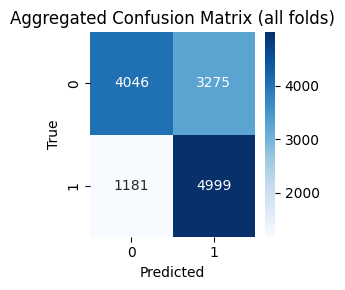

KNN | Time taken: 0.57

Evaluating: AdaBoost
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.72      0.52      0.60      1948
           1       0.64      0.81      0.72      2092

    accuracy                           0.67      4040
   macro avg       0.68      0.66      0.66      4040
weighted avg       0.68      0.67      0.66      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      3535
           1       0.64      0.66      0.65      1794

    accuracy                           0.76      5329
   macro avg       0.73      0.74      0.73      5329
weighted avg       0.76      0.76      0.76      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       935
           1       0.51      0.55      0.53    

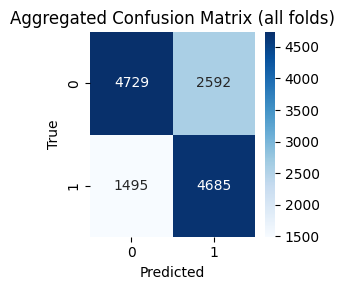

AdaBoost | Time taken: 17.20

Evaluating: LogisticRegression
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.71      0.58      0.64      1948
           1       0.67      0.78      0.72      2092

    accuracy                           0.68      4040
   macro avg       0.69      0.68      0.68      4040
weighted avg       0.69      0.68      0.68      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.71      0.17      0.27      3535
           1       0.35      0.86      0.49      1794

    accuracy                           0.40      5329
   macro avg       0.53      0.52      0.38      5329
weighted avg       0.59      0.40      0.35      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       935
           1       0.56      0.

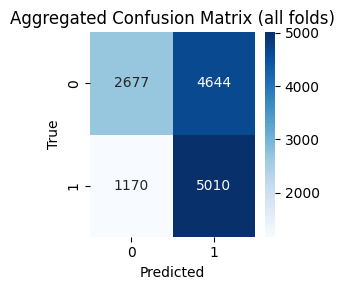

LogisticRegression | Time taken: 0.52

Evaluating: GaussianNB
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.82      0.28      0.42      1948
           1       0.58      0.94      0.72      2092

    accuracy                           0.62      4040
   macro avg       0.70      0.61      0.57      4040
weighted avg       0.70      0.62      0.58      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.86      0.35      0.50      3535
           1       0.41      0.89      0.56      1794

    accuracy                           0.53      5329
   macro avg       0.64      0.62      0.53      5329
weighted avg       0.71      0.53      0.52      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       935
           1       0.43      0

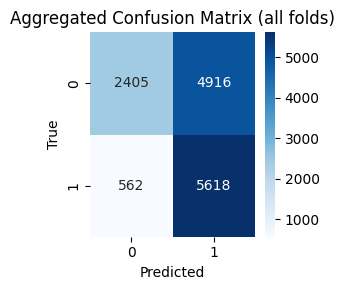

GaussianNB | Time taken: 0.33

Evaluating: SVC
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.69      0.59      0.64      1948
           1       0.66      0.75      0.71      2092

    accuracy                           0.67      4040
   macro avg       0.68      0.67      0.67      4040
weighted avg       0.68      0.67      0.67      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      3535
           1       0.54      0.74      0.63      1794

    accuracy                           0.70      5329
   macro avg       0.69      0.71      0.69      5329
weighted avg       0.74      0.70      0.71      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       935
           1       0.54      0.79      0.64  

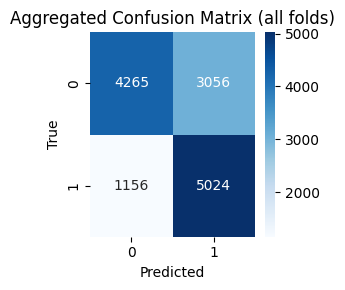

SVC | Time taken: 27.08

Evaluating: HistGradBoost
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.67      0.56      0.61      1948
           1       0.65      0.75      0.69      2092

    accuracy                           0.66      4040
   macro avg       0.66      0.66      0.65      4040
weighted avg       0.66      0.66      0.66      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.75      0.61      0.67      3535
           1       0.44      0.60      0.50      1794

    accuracy                           0.60      5329
   macro avg       0.59      0.60      0.59      5329
weighted avg       0.64      0.60      0.61      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       935
           1       0.59      0.62      0.

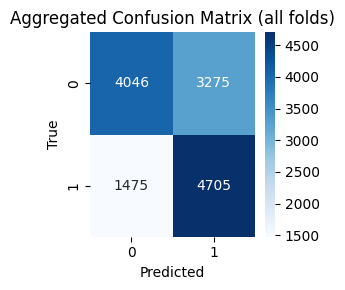

HistGradBoost | Time taken: 4.20

Evaluating: RF
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.72      0.59      0.65      1948
           1       0.67      0.79      0.73      2092

    accuracy                           0.69      4040
   macro avg       0.70      0.69      0.69      4040
weighted avg       0.70      0.69      0.69      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      3535
           1       0.60      0.55      0.57      1794

    accuracy                           0.72      5329
   macro avg       0.69      0.68      0.68      5329
weighted avg       0.72      0.72      0.72      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       935
           1       0.60      0.66      0.63

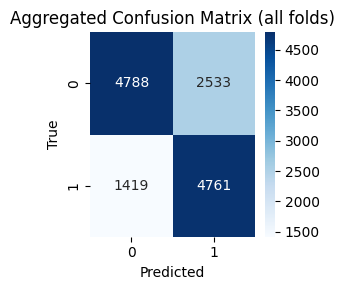

RF | Time taken: 8.58

Evaluating: Dummy_MostFrequent
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.48      1.00      0.65      1948
           1       0.00      0.00      0.00      2092

    accuracy                           0.48      4040
   macro avg       0.24      0.50      0.33      4040
weighted avg       0.23      0.48      0.31      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3535
           1       0.34      1.00      0.50      1794

    accuracy                           0.34      5329
   macro avg       0.17      0.50      0.25      5329
weighted avg       0.11      0.34      0.17      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       935
           1       0.00      0.00     

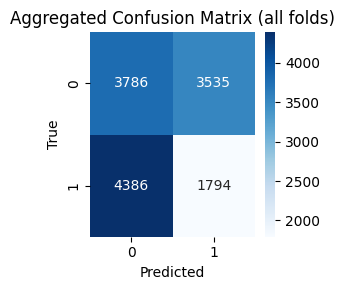

Dummy_MostFrequent | Time taken: 0.15

Evaluating: Dummy_Stratified
- - - - - - - - - - 

------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.49      0.59      0.54      1948
           1       0.53      0.44      0.48      2092

    accuracy                           0.51      4040
   macro avg       0.51      0.51      0.51      4040
weighted avg       0.51      0.51      0.51      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.66      0.45      0.54      3535
           1       0.33      0.54      0.41      1794

    accuracy                           0.48      5329
   macro avg       0.50      0.50      0.47      5329
weighted avg       0.55      0.48      0.50      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.70      0.53      0.60       935
           1       0.30 

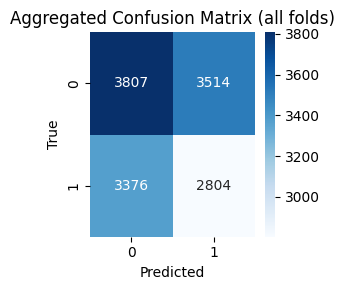

Dummy_Stratified | Time taken: 0.16


In [106]:
## suit of models
models = [
    ("KNN", KNeighborsClassifier(n_neighbors=50, n_jobs=-1)),
    ("AdaBoost", AdaBoostClassifier(n_estimators=350, random_state=0)),
    ("LogisticRegression", LogisticRegression(max_iter=1000)),
    ("GaussianNB", GaussianNB()),
    ("SVC", SVC(probability=True, kernel='rbf', C=1.0, random_state=0)),
    ("HistGradBoost", HistGradientBoostingClassifier(max_iter=500, random_state=0)),
    ("RF", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1)),
    ("Dummy_MostFrequent",DummyClassifier(strategy="most_frequent")),
    ("Dummy_Stratified",DummyClassifier(strategy="stratified"))
]

# dict to store results
big_dict_all_classifiers = {}

# Loop through models
for model_name, model in models:
    print(f"\n{'='*100}")
    print(f"Evaluating: {model_name}")
    print(f"{'- '*10}\n")
    
    start_time = time.time()
    
    # Create pipeline
    clf = Pipeline([
        ("preproc", preprocessor),
        (model_name, model)
    ])
    
    # Evaluate
    scores = evaluate_with_group_kfold(clf, X, y_vec, groups, verbose=True)
    
    # Create DataFrame from scores
    df_scores = pd.DataFrame(scores)
    
    # Display results
    print(f"\n--- Results for {model_name} ---")
    describe_kfold_results(df_scores)
    
    # Plot confusion matrix
    total_cm = np.sum(df_scores["confusion_matrix"].to_list(), axis=0)
    plot_cm(total_cm, figsize=(3,3))
    
    # Store results
    big_dict_all_classifiers[model_name] = df_scores
    
    time_taken =  time.time() - start_time
    print(f"{model_name} | Time taken: {time_taken:.2f}")

## ploting

In [ ]:
## Construct a multi-level df 
## the first column level is the name of the classifier and the second level are the metrics 
dfs = []
for model_name, df in big_dict_all_classifiers.items():
    # first level = model name, second level = metric name
    df.columns = pd.MultiIndex.from_product([[model_name], df.columns])
    dfs.append(df)

# concat
multi_df = pd.concat(dfs, axis=1)

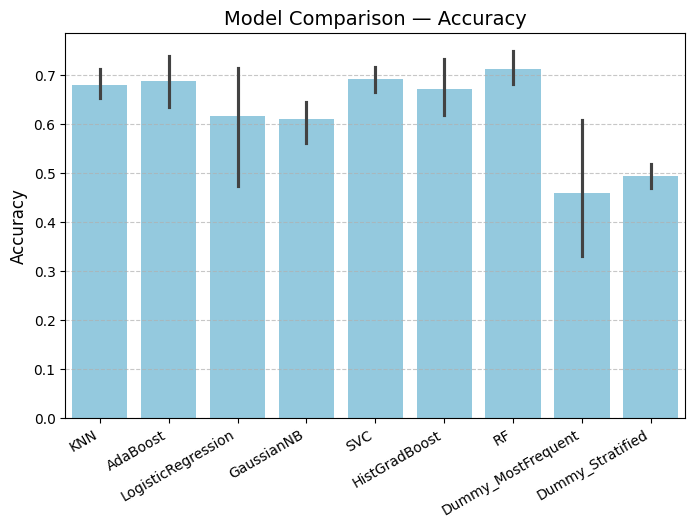

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=multi_df.xs('accuracy', level=1, axis=1),
            color='skyblue')
plt.title('Model Comparison — Accuracy', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Plotting in R 
cause R is cooler :)

In [ ]:
! uv pip install r

Using Python 3.12.11 environment at: /Users/saharmohamed/Documents/ML_Project/.venv
  × No solution found when resolving dependencies:                                  
  ╰─▶ Because r was not found in the package registry and you require r, we
      can conclude that your requirements are unsatisfiable.


In [ ]:
!uv pip install rpy2

Using Python 3.12.11 environment at: /Users/saharmohamed/Documents/ML_Project/.venv
Audited 1 package in 1ms


In [ ]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/saharmohamed/Documents/ML_Project/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <05EE76C0-33BF-3D4C-BC56-84005241BC88> /Users/saharmohamed/Documents/ML_Project/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [ ]:
from src.utils import export_cv_clfs_metrics
import os

## exporting my table in folder
export_cv_clfs_metrics(big_dict_all_classifiers,
                       export=True,
                       file_name='model_results')

## vars 
file_output = "result_imgs/"
width = 9
height = 7
dpi=100

In [ ]:
%%R -i file_output,width,height,dpi

library(ggplot2)
suppressMessages(library(dplyr))
suppressMessages(library(tidyverse))

## figsize
options(repr.plot.width = 10, repr.plot.height = 8)

# Load
dataf <- readr::read_csv("tmp_csv/model_results.csv", col_names=TRUE, show_col_types = FALSE)
metrics_col <- c("recall","precision","f1","accuracy","balanced_accuracy","roc_auc")

## exclude confusion matrix
datafilter <- dataf |> 
                    filter(metric != "confusion_matrix") |>
                    mutate(value = as.numeric(value))
# plot
p <- ggplot(datafilter |> filter(metric != "kfold"),
            aes(x = model, y = value, fill = metric)
        ) +
  stat_summary(fun = mean, geom = "bar", position = "dodge") +
  stat_summary(fun.data = mean_se, geom = "errorbar", 
               #position = position_dodge(width = 0.9),
                width = 0.05, color='#444343ff') +
  labs(title = "Models Performance",
       x = NULL, y = "Score") +
    scale_fill_brewer(palette = "Blues")+
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
            plot.background = element_rect(fill = "#eaf2f8", color = NA),
            plot.title = element_text(hjust = 0.5, face = "bold")
        ) 
    
##print(p) 

ggsave(file_output,    
       width = width,           
       height = height,          
       dpi = dpi)  

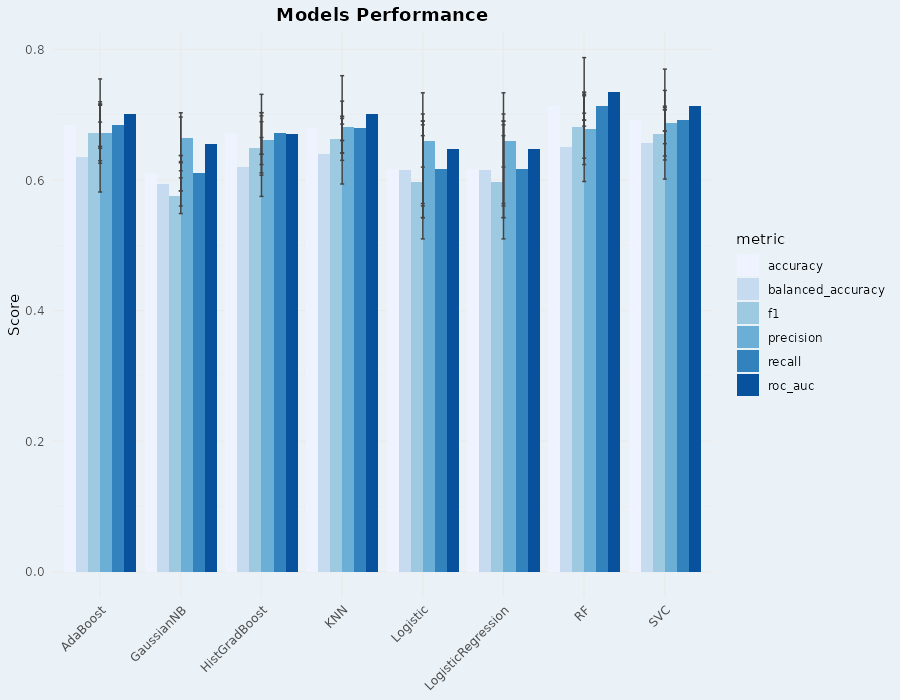

In [ ]:
from IPython.display import Image

Image(file_output, width=width*dpi, height=height*dpi)

## Featire Selection with 2 splits

Fold 0: acc shape = (39,), rec shape = (39,), raw features = 39
Fold 1: acc shape = (39,), rec shape = (39,), raw features = 39


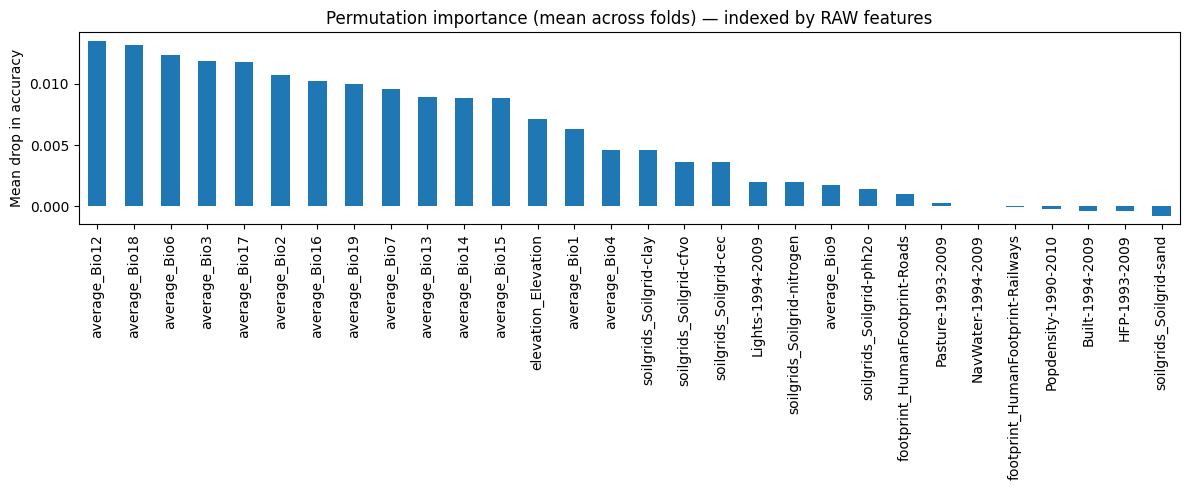

average_Bio12                        0.013481
average_Bio18                        0.013186
average_Bio6                         0.012335
average_Bio3                         0.011877
average_Bio17                        0.011782
average_Bio2                         0.010716
average_Bio16                        0.010207
average_Bio19                        0.009943
average_Bio7                         0.009564
average_Bio13                        0.008927
average_Bio14                        0.008857
average_Bio15                        0.008817
elevation_Elevation                  0.007121
average_Bio1                         0.006348
average_Bio4                         0.004637
soilgrids_Soilgrid-clay              0.004603
soilgrids_Soilgrid-cfvo              0.003657
soilgrids_Soilgrid-cec               0.003605
Lights-1994-2009                     0.002012
soilgrids_Soilgrid-nitrogen          0.001960
average_Bio9                         0.001713
soilgrids_Soilgrid-phh2o          

In [ ]:
from sklearn.inspection import permutation_importance

n_splits = 2
gkf = GroupKFold(n_splits=n_splits,
                 shuffle=True,
                 random_state=420)
groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

raw_feat_names = X.columns.to_list()   # RAW feature names
# perm_vals = []
perm_vals_acc = []
perm_vals_rec = []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_vec.iloc[train_idx], y_vec.iloc[test_idx]

    pipe = Pipeline([
        ("preproc", preprocessor),   # the ColumnTransformer
        ("clf", RandomForestClassifier(n_estimators=700,
                                       random_state=0,
                                       n_jobs=-1)
        )
    ])
    
    
    pipe.fit(X_train, y_train) 

    # compute permutation importance ON THE RAW X_test
    r = permutation_importance(pipe, X_test, y_test, n_repeats=5, random_state=0, n_jobs=-1, scoring=['accuracy','recall'])
    acc_imp = r['accuracy']
    rec_imp = r['recall']
    print(f"Fold {fold_i}: "
      f"acc shape = {acc_imp.importances_mean.shape}, "
      f"rec shape = {rec_imp.importances_mean.shape}, "
      f"raw features = {len(raw_feat_names)}")
    perm_vals_acc.append(acc_imp.importances_mean)
    perm_vals_rec.append(rec_imp.importances_mean)
    # print(f"Fold {fold_i}: perm importances shape = {r.importances_mean.shape}, raw features = {len(raw_feat_names)}")
    
    ## now the r is a dictionary with accuracy, recall 
    # perm_vals.append(r['accuracy'].importances_mean)

# stack and average across folds
perm_arr = np.vstack(perm_vals_acc)                # shape (n_splits, n_raw_features)
perm_mean = perm_arr.mean(axis=0)              # length == n_raw_features

# Create a Series indexed by RAW feature names
perm_series = pd.Series(perm_mean, index=raw_feat_names).sort_values(ascending=False)

# Plot top 25 raw features
plt.figure(figsize=(12,5))
perm_series.head(30).plot(kind='bar')
plt.title("Permutation importance (mean across folds) — indexed by RAW features")
plt.ylabel("Mean drop in accuracy")
plt.tight_layout()
plt.show()

# Print the top features
print(perm_series.head(40))

## using 4 splits

Fold 0: acc shape = (39,), rec shape = (39,), raw features = 39
Fold 1: acc shape = (39,), rec shape = (39,), raw features = 39
Fold 2: acc shape = (39,), rec shape = (39,), raw features = 39
Fold 3: acc shape = (39,), rec shape = (39,), raw features = 39


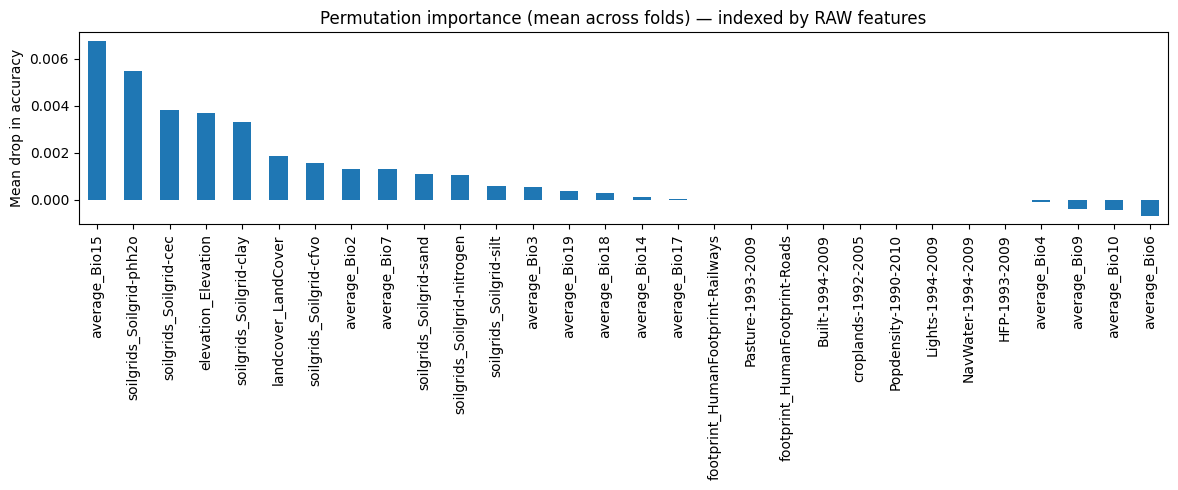

average_Bio15                        0.006743
soilgrids_Soilgrid-phh2o             0.005478
soilgrids_Soilgrid-cec               0.003838
elevation_Elevation                  0.003674
soilgrids_Soilgrid-clay              0.003313
landcover_LandCover                  0.001848
soilgrids_Soilgrid-cfvo              0.001581
average_Bio2                         0.001325
average_Bio7                         0.001296
soilgrids_Soilgrid-sand              0.001115
soilgrids_Soilgrid-nitrogen          0.001078
soilgrids_Soilgrid-silt              0.000604
average_Bio3                         0.000528
average_Bio19                        0.000379
average_Bio18                        0.000295
average_Bio14                        0.000142
average_Bio17                        0.000035
footprint_HumanFootprint-Railways    0.000000
Pasture-1993-2009                    0.000000
footprint_HumanFootprint-Roads       0.000000
Built-1994-2009                      0.000000
croplands-1992-2005               

In [132]:
from sklearn.inspection import permutation_importance

n_splits = 4
gkf = GroupKFold(n_splits=n_splits,
                 shuffle=True,
                 random_state=420)
groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

raw_feat_names = X.columns.to_list()   # RAW feature names
# perm_vals = []
perm_vals_acc = []
perm_vals_rec = []

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_vec.iloc[train_idx], y_vec.iloc[test_idx]

    pipe = Pipeline([
        ("preproc", preprocessor),   # the ColumnTransformer
        ("clf", RandomForestClassifier(n_estimators=700,
                                       random_state=0,
                                       n_jobs=-1)
        )
    ])
    
    
    pipe.fit(X_train, y_train) 

    # compute permutation importance ON THE RAW X_test
    r = permutation_importance(pipe, X_test, y_test, n_repeats=5, random_state=0, n_jobs=-1, scoring=['accuracy','recall'])
    acc_imp = r['accuracy']
    rec_imp = r['recall']
    print(f"Fold {fold_i}: "
      f"acc shape = {acc_imp.importances_mean.shape}, "
      f"rec shape = {rec_imp.importances_mean.shape}, "
      f"raw features = {len(raw_feat_names)}")
    perm_vals_acc.append(acc_imp.importances_mean)
    perm_vals_rec.append(rec_imp.importances_mean)
    # print(f"Fold {fold_i}: perm importances shape = {r.importances_mean.shape}, raw features = {len(raw_feat_names)}")
    
    ## now the r is a dictionary with accuracy, recall 
    # perm_vals.append(r['accuracy'].importances_mean)

# stack and average across folds
perm_arr = np.vstack(perm_vals_acc)                # shape (n_splits, n_raw_features)
perm_mean = perm_arr.mean(axis=0)              # length == n_raw_features

# Create a Series indexed by RAW feature names
perm_series = pd.Series(perm_mean, index=raw_feat_names).sort_values(ascending=False)

# Plot top 25 raw features
plt.figure(figsize=(12,5))
perm_series.head(30).plot(kind='bar')
plt.title("Permutation importance (mean across folds) — indexed by RAW features")
plt.ylabel("Mean drop in accuracy")
plt.tight_layout()
plt.show()

# Print the top features
print(perm_series.head(40))

In [109]:
# threshold (0 means dropping negative and zero)

from sklearn.model_selection import cross_validate
from src.inference import evaluate_with_group_kfold, describe_kfold_results
from src.plot import plot_cm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

threshold = 0.0
keep_features = perm_series[perm_series > threshold].index.tolist()
drop_features = [f for f in X.columns if f not in keep_features]

print(f"Keeping {len(keep_features)} features, dropping {len(drop_features)} features")
print(f"The selected features are: {len(keep_features)}") ## Print selected Features 

## Select new X
X_reduced = X[keep_features].copy()
groups_reduced = df.loc[X_reduced.index, 'GRECO']


cat_cols = [c for c in X_reduced.columns if c.startswith('landcover') or X_reduced[c].dtype == 'object']
num_cols = [c for c in X_reduced.columns if c not in cat_cols]

preprocessor_reduced = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

## new pipeline with reduced features
pipe_reduced = Pipeline([
    ("preproc", preprocessor_reduced),
    ("clf", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1))
])


## Re-use the preprocessor >>> We can't use the same preprocessor heer as the features have changed
# pipe_reduced = Pipeline([("preproc", preprocessor),("clf", RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1))])

print("\nEvaluating RF on reduced feature set:")
res_reduced = evaluate_with_group_kfold(pipe_reduced,
                                        X_reduced,
                                        y_vec,
                                        groups=groups_reduced
                                        )

# Evaluate original (on full X) and reduced (X_reduced)
print("Evaluating original RF on full X:")
res_full = evaluate_with_group_kfold(Pipeline([("preproc", preprocessor),
                                               ("clf", RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1))]
                                              ),
                                                X, ##full X
                                                y_vec,
                                                groups=df.loc[X.index,'GRECO'],
                                                verbose=True)


df_scores_full = pd.DataFrame(res_full)
df_scores_red = pd.DataFrame(res_reduced)

describe_kfold_results(df_scores_full)
describe_kfold_results(df_scores_red)

# ## FINISH
# print("\nMean accuracy full: {:.4f}".format(np.mean(res_full['accuracy'])))
# print("Mean accuracy reduced: {:.4f}".format(np.mean(res_reduced['accuracy'])))

df_full = pd.DataFrame(res_full)
df_red = pd.DataFrame(res_reduced)

print(df_full['accuracy'].mean())
print(df_red['accuracy'].mean())


# print("\nMean accuracy full: {:.4f}".format(res_full['summary_df']['accuracy'].mean()))
# print("Mean accuracy reduced: {:.4f}".format(res_reduced['summary_df']['accuracy'].mean()))


Keeping 27 features, dropping 12 features
The selected features are: 27

Evaluating RF on reduced feature set:
Evaluating original RF on full X:
------------------------------
Folder: 0
              precision    recall  f1-score   support

           0       0.72      0.59      0.65      1948
           1       0.67      0.79      0.73      2092

    accuracy                           0.69      4040
   macro avg       0.70      0.69      0.69      4040
weighted avg       0.70      0.69      0.69      4040

------------------------------
Folder: 1
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      3535
           1       0.60      0.55      0.57      1794

    accuracy                           0.72      5329
   macro avg       0.69      0.68      0.68      5329
weighted avg       0.72      0.72      0.72      5329

------------------------------
Folder: 2
              precision    recall  f1-score   support

           0       0.85

In [ ]:
#pd.Series(keep_features).to_csv("selected_features.csv", index=False, header=["feature"])
## save with index
pd.Series(keep_features).to_csv("selected_features_index.csv", index=True, header=["feature"])

print("\nSelected Features:")
for i, f in enumerate(keep_features, 1):
    print(f"{i}. {f}")

    

#### Training using X_full datasets, X_with only Feature Selection, and X_mod without HFP

In [89]:
X.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc',
       'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
       'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
       'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
       'HFP-1993-2009'],
      dtype='object')

In [90]:
X_full = X.copy()
groups_full = df.loc[X_full.index, 'GRECO']


In [143]:
hf_cols = [
    'footprint_HumanFootprint-Railways', 'footprint_HumanFootprint-Roads',
    'Built-1994-2009', 'croplands-1992-2005', 'Lights-1994-2009',
    'NavWater-1994-2009', 'Pasture-1993-2009', 'Popdensity-1990-2010',
    'HFP-1993-2009'
]

X_mod = X.drop(columns=[c for c in hf_cols if c in X.columns]).copy()
groups_mod = df.loc[X_mod.index, 'GRECO']



selected_features = [
    'elevation_Elevation','average_Bio1','average_Bio11','landcover_LandCover',
    'soilgrids_Soilgrid-soc','average_Bio6','average_Bio19','soilgrids_Soilgrid-phh2o',
    'average_Bio15','average_Bio2','soilgrids_Soilgrid-cfvo','average_Bio7',
    'soilgrids_Soilgrid-sand','Lights-1994-2009','HFP-1993-2009','soilgrids_Soilgrid-cec',
    'average_Bio8','soilgrids_Soilgrid-bdod','croplands-1992-2005','soilgrids_Soilgrid-clay',
    'Popdensity-1990-2010','Pasture-1993-2009','average_Bio5','average_Bio14',
    'average_Bio3','Built-1994-2009','soilgrids_Soilgrid-nitrogen'
]

X_red = X[selected_features].copy()
groups_red = df.loc[X_red.index, 'GRECO']

## Build preprocessor function 
def build_preprocessor(df):
    numeric_cols = df.select_dtypes(include=['int', 'float']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipeline = Pipeline([
        # ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])

    preproc = ColumnTransformer([
        ("num", num_pipeline, numeric_cols),
        ("cat", cat_pipeline, categorical_cols),
    ])

    return preproc



## Preprocessor Pipline for each dataset
pipe_full = Pipeline([
    ("preproc", build_preprocessor(X_full)),
    ("clf", RandomForestClassifier(n_estimators=700, n_jobs=-1, random_state=0))
])

pipe_red = Pipeline([
    ("preproc", build_preprocessor(X_red)),
    ("clf", RandomForestClassifier(n_estimators=700, n_jobs=-1, random_state=0))
])

pipe_mod = Pipeline([
    ("preproc", build_preprocessor(X_mod)),
    ("clf", RandomForestClassifier(n_estimators=700, n_jobs=-1, random_state=0))
])


In [144]:
## K-fold evaluation for each dataset
res_full = evaluate_with_group_kfold(pipe_full, X_full, y_vec, groups=groups_full)
res_red  = evaluate_with_group_kfold(pipe_red, X_red,  y_vec, groups=groups_red)
res_mod  = evaluate_with_group_kfold(pipe_mod, X_mod,  y_vec, groups=groups_mod)

## DataFrames for each result
df_full = pd.DataFrame(res_full)
df_red  = pd.DataFrame(res_red)
df_mod  = pd.DataFrame(res_mod)


mean_full = df_full['accuracy'].mean()
mean_red  = df_red['accuracy'].mean()
mean_mod  = df_mod['accuracy'].mean()

print("FULL accuracy:", mean_full)
print("REDUCED accuracy with FI:", mean_red)
print("MODIFIED accuracy without HFP:", mean_mod)


FULL accuracy: 0.7109409660841801
REDUCED accuracy with FI: 0.7069076633753535
MODIFIED accuracy without HFP: 0.7103392859966015


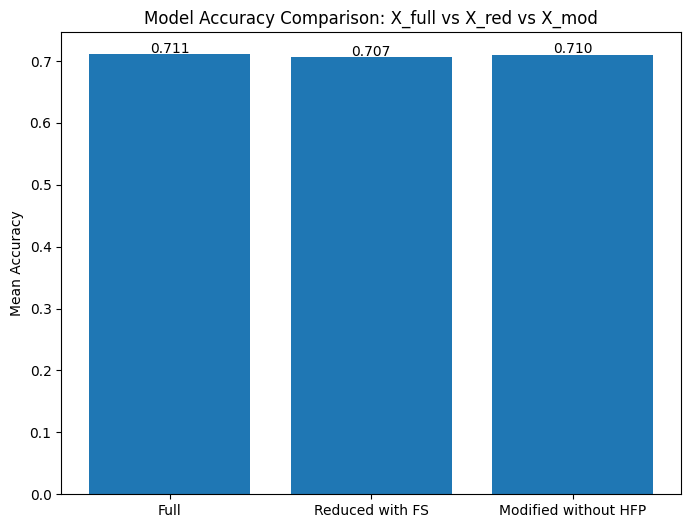

In [145]:
import matplotlib.pyplot as plt

methods = ['Full', 'Reduced with FS', 'Modified without HFP']
values = [mean_full, mean_red, mean_mod]

plt.figure(figsize=(8,6))
plt.bar(methods, values)
plt.ylabel("Mean Accuracy")
plt.title("Model Accuracy Comparison: X_full vs X_red vs X_mod")

# Highlight differences on bars
for i, val in enumerate(values):
    plt.text(i, val + 0.002, f"{val:.3f}", ha='center')

plt.show()


#### 
A comparison between the full feature set (accuracy = 0.7109) and the reduced model composed of 27 permutation-importance-selected features (accuracy = 0.7069) reveals a slight decrease in predictive performance.
This indicates that the removed variables still carry complementary information and that the reduced model, although more compact, does not outperform the baseline.

In contrast, the model evaluated without Human Footprint predictors (accuracy = 0.7103) performs almost identically to the full model, with a negligible loss (<0.1%).
This suggests that anthropogenic pressure variables provide minimal predictive value for our task, and that model performance is primarily driven by environmental and climatic variables.

## PCA

In [135]:
## Applying PCA
from sklearn.decomposition import PCA
n_splits = 4
gkf = GroupKFold(n_splits=n_splits,
                 shuffle=True,
                 random_state=420)
groups = df.loc[X.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_vec.iloc[train_idx], y_vec.iloc[test_idx]

In [136]:
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

results_pca3 = []
results_pca4 = []
results_pca_sel = []

model = RandomForestClassifier(n_estimators=700, random_state=0, n_jobs=-1)


for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, y_vec, groups=groups)):

    print(f"\n===== Fold {fold_i} =====")

    # Split
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y_vec.iloc[train_idx]
    y_test  = y_vec.iloc[test_idx]

    # scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # pca model with 3,4 and selected components
    pca3 = PCA(n_components=3)
    X_train_pca3 = pca3.fit_transform(X_train_scaled)
    X_test_pca3  = pca3.transform(X_test_scaled)

    model.fit(X_train_pca3, y_train)
    preds = model.predict(X_test_pca3)
    acc3 = accuracy_score(y_test, preds)
    results_pca3.append(acc3)

    print(f"PCA 3 comps: {acc3:.4f}")

    
    pca4 = PCA(n_components=4)
    X_train_pca4 = pca4.fit_transform(X_train_scaled)
    X_test_pca4  = pca4.transform(X_test_scaled)

    model.fit(X_train_pca4, y_train)
    preds = model.predict(X_test_pca4)
    acc4 = accuracy_score(y_test, preds)
    results_pca4.append(acc4)

    print(f"PCA 4 comps: {acc4:.4f}")

    # PCA selected (95% variance) 
    pca_full = PCA().fit(X_train_scaled)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    n95 = np.argmax(cum >= 0.95) + 1

    pca_sel = PCA(n_components=n95)
    X_train_sel = pca_sel.fit_transform(X_train_scaled)
    X_test_sel  = pca_sel.transform(X_test_scaled)

    model.fit(X_train_sel, y_train)
    preds = model.predict(X_test_sel)
    acc_sel = accuracy_score(y_test, preds)
    results_pca_sel.append(acc_sel)

    print(f"PCA selected ({n95} comps): {acc_sel:.4f}")



===== Fold 0 =====
PCA 3 comps: 0.6079
PCA 4 comps: 0.6592
PCA selected (16 comps): 0.6881

===== Fold 1 =====
PCA 3 comps: 0.6643
PCA 4 comps: 0.6857
PCA selected (17 comps): 0.6239

===== Fold 2 =====
PCA 3 comps: 0.4981
PCA 4 comps: 0.5273
PCA selected (18 comps): 0.7282

===== Fold 3 =====
PCA 3 comps: 0.6441
PCA 4 comps: 0.6602
PCA selected (17 comps): 0.6670


In [138]:
print("\n=== PCA Summary ===")
print(f"Mean PCA 3 comps:  {np.mean(results_pca3):.4f}")
print(f"Mean PCA 4 comps:  {np.mean(results_pca4):.4f}")
print(f"Mean PCA 95% var:  {np.mean(results_pca_sel):.4f}")



=== PCA Summary ===
Mean PCA 3 comps:  0.6036
Mean PCA 4 comps:  0.6331
Mean PCA 95% var:  0.6768


#### Here PCA perform worse 

## Grid SearchCV
  

In [123]:
X_mod.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc'],
      dtype='object')

In [124]:
X_red.columns

Index(['elevation_Elevation', 'average_Bio1', 'average_Bio11',
       'landcover_LandCover', 'soilgrids_Soilgrid-soc', 'average_Bio6',
       'average_Bio19', 'soilgrids_Soilgrid-phh2o', 'average_Bio15',
       'average_Bio2', 'soilgrids_Soilgrid-cfvo', 'average_Bio7',
       'soilgrids_Soilgrid-sand', 'Lights-1994-2009', 'HFP-1993-2009',
       'soilgrids_Soilgrid-cec', 'average_Bio8', 'soilgrids_Soilgrid-bdod',
       'croplands-1992-2005', 'soilgrids_Soilgrid-clay',
       'Popdensity-1990-2010', 'Pasture-1993-2009', 'average_Bio5',
       'average_Bio14', 'average_Bio3', 'Built-1994-2009',
       'soilgrids_Soilgrid-nitrogen'],
      dtype='object')

## using X-mod without HFP

In [146]:
# Define columns
cat_cols = [c for c in X_mod.columns if X_mod[c].dtype == 'object' or c.startswith('landcover')]
num_cols = [c for c in X_mod.columns if c not in cat_cols]

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# RF pipeline
pipe_rf = Pipeline([
    ("preproc", preprocessor),
    ("clf", RandomForestClassifier(random_state=0))
])

# Hyperparameter grid
param_grid_rf = {
    "clf__n_estimators": [100, 200, 700, 1000],
    "clf__max_depth": [None, 10, 20, 30]
    # "clf__min_samples_split": [2, 5, 10]
    # "clf__min_samples_leaf": [1, 2, 4]
}

# Group KFold
gkf = GroupKFold(n_splits=4, random_state=420, shuffle=True)

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=gkf.split(X_mod, y_vec, groups=groups_mod),
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

# Fit
grid_rf.fit(X_mod, y_vec)

# Best parameters & score
print("Best RF params:", grid_rf.best_params_)
print("Best RF accuracy:", grid_rf.best_score_)


Fitting 4 folds for each of 16 candidates, totalling 64 fits
[CV] END .........clf__max_depth=None, clf__n_estimators=100; total time=   2.0s
[CV] END .........clf__max_depth=None, clf__n_estimators=100; total time=   2.1s
[CV] END .........clf__max_depth=None, clf__n_estimators=100; total time=   2.3s
[CV] END .........clf__max_depth=None, clf__n_estimators=100; total time=   2.9s
[CV] END .........clf__max_depth=None, clf__n_estimators=200; total time=   4.1s
[CV] END .........clf__max_depth=None, clf__n_estimators=200; total time=   4.2s
[CV] END .........clf__max_depth=None, clf__n_estimators=200; total time=   4.7s
[CV] END .........clf__max_depth=None, clf__n_estimators=200; total time=   5.7s
[CV] END ...........clf__max_depth=10, clf__n_estimators=100; total time=   1.3s
[CV] END ...........clf__max_depth=10, clf__n_estimators=100; total time=   1.2s
[CV] END ...........clf__max_depth=10, clf__n_estimators=100; total time=   1.6s
[CV] END ...........clf__max_depth=10, clf__n_es

In [ ]:
# Best parameters & score
print("Best RF params:", grid_rf.best_params_)
print("Best RF accuracy:", grid_rf.best_score_)
## save the cv results

pd.DataFrame(grid_rf.cv_results_).to_csv("rf_gridsearchcv_results.csv", index=False)

Best RF params: {'clf__max_depth': None, 'clf__n_estimators': 700}
Best RF accuracy: 0.7138571303267442


In [150]:
pd.DataFrame(grid_rf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__max_depth,param_clf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
0,2.303728,0.351602,0.033166,0.010454,None,100,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.667327,0.721711,0.768484,0.661654,0.704794,0.043610,15,0.997252,0.999755,0.997780,0.997479,0.998066,0.000993
1,4.609166,0.671337,0.052276,0.020895,None,200,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.681436,0.719084,0.755788,0.669173,0.706370,0.033945,13,0.997358,0.999755,0.997780,0.997479,0.998093,0.000972
2,15.197448,2.305661,0.172576,0.060368,None,700,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.692574,0.724339,0.763256,0.675260,0.713857,0.033514,1,0.997358,0.999755,0.997780,0.997479,0.998093,0.000972
3,21.909304,3.557946,0.246116,0.074699,None,1000,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.691089,0.723400,0.761763,0.675976,0.713057,0.032927,3,0.997358,0.999755,0.997780,0.997479,0.998093,0.000972
4,1.370562,0.173837,0.017933,0.005960,10,100,"{'clf__max_depth': 10, 'clf__n_estimators': 100}",0.685396,0.733721,0.731143,0.675618,0.706469,0.026208,12,0.866822,0.846672,0.853478,0.884946,0.862979,0.014607
5,2.818072,0.388904,0.030358,0.012569,10,200,"{'clf__max_depth': 10, 'clf__n_estimators': 200}",0.693812,0.721711,0.732636,0.674185,0.705586,0.023002,14,0.866505,0.847528,0.852162,0.885973,0.863042,0.014974
6,10.206911,1.341173,0.110420,0.039954,10,700,"{'clf__max_depth': 10, 'clf__n_estimators': 700}",0.689109,0.731657,0.730396,0.676692,0.706963,0.024464,9,0.867033,0.848507,0.852245,0.885600,0.863346,0.014597
7,15.374211,2.025557,0.181803,0.067134,10,1000,"{'clf__max_depth': 10, 'clf__n_estimators': 1000}",0.692079,0.730906,0.730396,0.677050,0.707608,0.023649,8,0.867562,0.849364,0.852574,0.886440,0.863985,0.014672
8,2.283385,0.366409,0.026816,0.010807,20,100,"{'clf__max_depth': 20, 'clf__n_estimators': 100}",0.680693,0.727904,0.750560,0.668457,0.706903,0.033586,10,0.990487,0.982012,0.968180,0.983284,0.980991,0.008072
9,4.538431,0.649397,0.055329,0.020669,20,200,"{'clf__max_depth': 20, 'clf__n_estimators': 200}",0.675990,0.726403,0.755041,0.669889,0.706831,0.035437,11,0.992178,0.985928,0.968755,0.984591,0.982863,0.008634


## SVC Hyperparametr Tuning

In [148]:
X_mod.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc'],
      dtype='object')

In [157]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define columns
cat_cols = [c for c in X_mod.columns if X_mod[c].dtype == 'object' or c.startswith('landcover')]
num_cols = [c for c in X_mod.columns if c not in cat_cols]

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])
pipe_svc = Pipeline([
    ("preproc", preprocessor),
    ("clf", SVC(random_state=0))
])

param_grid_svc = {
    "clf__C": [0.1, 1, 10, 50, 100],
    "clf__kernel": ['rbf', 'linear'],
    "clf__gamma": ['scale', 'auto']
}

grid_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    cv=gkf.split(X_mod, y_vec, groups=groups),
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_svc.fit(X_mod, y_vec)
print("Best SVC params:", grid_svc.best_params_)
print("Best SVC accuracy:", grid_svc.best_score_)


Fitting 4 folds for each of 20 candidates, totalling 80 fits
[CV] END ...clf__C=0.1, clf__gamma=scale, clf__kernel=linear; total time=   2.3s
[CV] END ...clf__C=0.1, clf__gamma=scale, clf__kernel=linear; total time=   2.5s
[CV] END ...clf__C=0.1, clf__gamma=scale, clf__kernel=linear; total time=   2.6s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   2.9s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   3.0s
[CV] END .......clf__C=0.1, clf__gamma=auto, clf__kernel=rbf; total time=   3.0s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   3.1s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   3.4s
[CV] END .......clf__C=0.1, clf__gamma=auto, clf__kernel=rbf; total time=   3.3s
[CV] END ...clf__C=0.1, clf__gamma=scale, clf__kernel=linear; total time=   3.8s
[CV] END ....clf__C=0.1, clf__gamma=auto, clf__kernel=linear; total time=   2.6s
[CV] END ....clf__C=0.1, clf__gamma=auto, clf__k

In [ ]:
pd.DataFrame(grid_svc.cv_results_).to_csv("svc_gridsearchcv_results.csv", index=False)

## Testing the models

Here we gonna train the choose ML model in the full dataset with the hyperparameters tunned and apply to the yTEST

Lets repeat this with the full Xtrain features and with the Xtrain features selected.

In [162]:
X_mod.columns

Index(['average_Bio1', 'average_Bio2', 'average_Bio3', 'average_Bio4',
       'average_Bio5', 'average_Bio6', 'average_Bio7', 'average_Bio8',
       'average_Bio9', 'average_Bio10', 'average_Bio11', 'average_Bio12',
       'average_Bio13', 'average_Bio14', 'average_Bio15', 'average_Bio16',
       'average_Bio17', 'average_Bio18', 'average_Bio19',
       'elevation_Elevation', 'landcover_LandCover', 'soilgrids_Soilgrid-bdod',
       'soilgrids_Soilgrid-cec', 'soilgrids_Soilgrid-cfvo',
       'soilgrids_Soilgrid-clay', 'soilgrids_Soilgrid-nitrogen',
       'soilgrids_Soilgrid-phh2o', 'soilgrids_Soilgrid-sand',
       'soilgrids_Soilgrid-silt', 'soilgrids_Soilgrid-soc'],
      dtype='object')

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# Best params from GridSearch
best_params_svc = {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
best_params_rf  = {'max_depth': None, 'n_estimators': 700}

svc_fold_acc = []
rf_fold_acc = []

n_splits = 4
gkf = GroupKFold(n_splits=n_splits,
                 shuffle=True,
                 random_state=420)
groups = df.loc[X_mod.index, 'GRECO']
y_vec = y['predict'] if isinstance(y, pd.DataFrame) else y

for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X_mod, y_vec, groups=groups)):
    print(f"\n===== Fold {fold_i} =====")

    # -------------------------
    # TRAIN / TEST SPLIT
    # -------------------------
    X_train = X_mod.iloc[train_idx]
    X_test  = X_mod.iloc[test_idx]
    y_train = y_vec.iloc[train_idx]
    y_test  = y_vec.iloc[test_idx]

    # -------------------------
    # SVC MODEL (BEST PARAMS)
    # -------------------------
    svc_model = SVC(**best_params_svc, probability=True, random_state=0)
    svc_model.fit(X_train, y_train)
    svc_pred = svc_model.predict(X_test)

    acc_svc = accuracy_score(y_test, svc_pred)
    svc_fold_acc.append(acc_svc)

    print(f"SVC Accuracy Fold {fold_i}: {acc_svc:.4f}")

    # -------------------------
    # RANDOM FOREST MODEL (BEST PARAMS)
    # -------------------------
    rf_model = RandomForestClassifier(**best_params_rf, random_state=0, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)

    acc_rf = accuracy_score(y_test, rf_pred)
    rf_fold_acc.append(acc_rf)

    print(f"RF Accuracy Fold {fold_i}: {acc_rf:.4f}")

# -------------------------
# SUMMARY RESULTS
# -------------------------
print("\n=== FINAL CROSS-FOLD RESULTS ===")
print(f"SVC mean accuracy: {np.mean(svc_fold_acc):.4f}")
print(f"RF  mean accuracy: {np.mean(rf_fold_acc):.4f}")



===== Fold 0 =====


## Error Evaluation

-Here we are tring to evaluate the error of the model.
- Lets focus on see if we find bias on the prediction and how the spatial distribution the error is given
- For the same area, try to apply some UMAP to see if the feature space is very similar and therefore the model is predicting a true label as false

## 